<a href="https://colab.research.google.com/github/Sriyansh-36-AI-NITJ/Deep-Learning-Lab/blob/main/25901336_R_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

# 1. Install required packages
!pip install python-docx opencv-contrib-python

# 2. Create a directory for the dataset
VOC_DIR = '/content/voc_data'
os.makedirs(VOC_DIR, exist_ok=True)

# 3. Download the PASCAL VOC 2007 training/validation and test data
!wget -P {VOC_DIR} http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
!wget -P {VOC_DIR} http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtest_06-Nov-2007.tar

# 4. Extract the downloaded archives into the directory
!tar -xf {VOC_DIR}/VOCtrainval_06-Nov-2007.tar -C {VOC_DIR}
!tar -xf {VOC_DIR}/VOCtest_06-Nov-2007.tar -C {VOC_DIR}

# 5. Verify the successful extraction
extracted_path = os.path.join(VOC_DIR, 'VOCdevkit', 'VOC2007')
if os.path.exists(extracted_path):
    print(f"Dataset extracted successfully to: {extracted_path}")
    print("Contents:", os.listdir(extracted_path))
else:
    print("Extraction failed or path structure is different than expected.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 9.1 MB/s eta 0:00:00
--2026-03-01 13:18:26--  http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
Resolving host.robots.ox.ac.uk (host.robots.ox.ac.uk)... 129.67.94.50
Connecting to host.robots.ox.ac.uk (host.robots.ox.ac.uk)|129.67.94.50|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar [following]
--2026-03-01 13:18:27--  https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.ta [following]
--2026-03-01 13:18:27--  https://thor.robots.ox.ac.uk/pascal/

In [2]:
import os

VOC_DIR = '/content/voc_data'
# Use the direct VGG mirror link which is usually more stable
trainval_url = 'http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar'

# Retry downloading trainval set
print('Downloading VOC2007 trainval set...')
!wget -c -P {VOC_DIR} {trainval_url}

# Extract the newly downloaded archive
print('Extracting trainval set...')
!tar -xf {VOC_DIR}/VOCtrainval_06-Nov-2007.tar -C {VOC_DIR}

# Final verification of the directory structure
extracted_path = os.path.join(VOC_DIR, 'VOCdevkit', 'VOC2007')
if os.path.exists(extracted_path):
    contents = os.listdir(extracted_path)
    print(f'Final check: {extracted_path} contains {contents}')
    required = ['Annotations', 'ImageSets', 'JPEGImages']
    if all(folder in contents for folder in required):
        print('Verification successful: All required folders are present.')
    else:
        print('Warning: Some required folders are missing.')
else:
    print('Extraction failed.')

--2026-03-01 13:18:55--  http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
Resolving host.robots.ox.ac.uk (host.robots.ox.ac.uk)... 129.67.94.50
Connecting to host.robots.ox.ac.uk (host.robots.ox.ac.uk)|129.67.94.50|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar [following]
--2026-03-01 13:18:55--  https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.ta [following]
--2026-03-01 13:18:56--  https://thor.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.ta
Resolving thor.robots.ox.ac.uk (thor.robo

## Step 1: Region Proposal Generation & Visualization



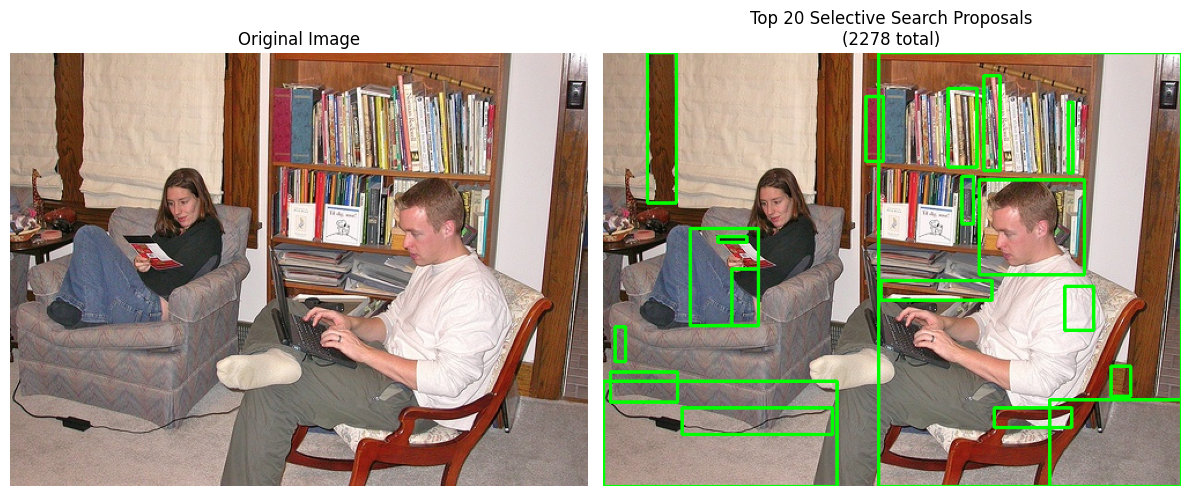

Processed image: 009708.jpg
Total region proposals generated: 2278


In [3]:
import cv2
import matplotlib.pyplot as plt
import random
import os

# 1. Select a random image from the JPEGImages directory
image_dir = os.path.join(extracted_path, 'JPEGImages')
image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
sample_image_name = random.choice(image_files)
sample_image_path = os.path.join(image_dir, sample_image_name)

# 2. Load the image and convert BGR to RGB
image = cv2.imread(sample_image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 3. Initialize Selective Search
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(image)

# 4. Use 'fast' mode for region proposal
ss.switchToSelectiveSearchFast()
rects = ss.process()

# 5. Draw the top 20 proposals
image_with_proposals = image_rgb.copy()
for i, rect in enumerate(rects):
    if i < 20:
        x, y, w, h = rect
        cv2.rectangle(image_with_proposals, (x, y), (x + w, y + h), (0, 255, 0), 2)
    else:
        break

# 6. Display the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(image_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f'Top 20 Selective Search Proposals\n({len(rects)} total)')
plt.imshow(image_with_proposals)
plt.axis('off')

plt.tight_layout()
plt.show()

print(f'Processed image: {sample_image_name}')
print(f'Total region proposals generated: {len(rects)}')

## Step 2: Feature Extraction Pipeline



In [4]:
import numpy as np
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image as keras_image
import cv2

# 1. Load pretrained VGG16 model
base_model = VGG16(weights='imagenet', include_top=True)

# 2. Create feature extractor by truncating at the 'fc2' layer (4096 dims)
feature_extractor = Model(inputs=base_model.input, outputs=base_model.get_layer('fc2').output)

def preprocess_proposal(img_crop):
    """
    Preprocesses an image crop for VGG16: resize to 224x224 and normalize.
    """
    # Resize to VGG16 input size
    img_resized = cv2.resize(img_crop, (224, 224))
    # Convert to array and add batch dimension
    x = keras_image.img_to_array(img_resized)
    x = np.expand_dims(x, axis=0)
    # Apply VGG16 specific preprocessing
    x = preprocess_input(x)
    return x

# 3. Test the pipeline with a dummy image
dummy_crop = np.random.randint(0, 255, (100, 100, 3), dtype=np.uint8)
preprocessed_input = preprocess_proposal(dummy_crop)
features = feature_extractor.predict(preprocessed_input)

print(f'Input shape: {preprocessed_input.shape}')
print(f'Extracted feature shape: {features.shape}')

if features.shape == (1, 4096):
    print('Verification successful: Output shape is (1, 4096).')
else:
    print(f'Verification failed: Expected (1, 4096), got {features.shape}.')

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Input shape: (1, 224, 224, 3)
Extracted feature shape: (1, 4096)
Verification successful: Output shape is (1, 4096).


## Step 3: Classifier Training


In [5]:
import xml.etree.ElementTree as ET
import os

def calculate_iou(boxA, boxB):
    # box = [x, y, w, h]
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0] + boxA[2], boxB[0] + boxB[2])
    yB = min(boxA[1] + boxA[3], boxB[1] + boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = boxA[2] * boxA[3]
    boxBArea = boxB[2] * boxB[3]
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

def parse_voc_annotation(ann_path):
    tree = ET.parse(ann_path)
    root = tree.getroot()
    boxes = []
    for obj in root.findall('object'):
        label = obj.find('name').text
        bndbox = obj.find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)
        # Convert to [x, y, w, h]
        boxes.append({'label': label, 'bbox': [xmin, ymin, xmax - xmin, ymax - ymin]})
    return boxes

print('IoU and XML parsing functions defined successfully.')

IoU and XML parsing functions defined successfully.


In [6]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. Configuration for data collection
num_train_images = 50
pos_iou_threshold = 0.5
neg_iou_threshold = 0.3
ann_dir = os.path.join(extracted_path, 'Annotations')
img_dir = os.path.join(extracted_path, 'JPEGImages')

X_train = []
y_train = []

# 2. Process a subset of images
for i in range(min(num_train_images, len(image_files))):
    img_name = image_files[i]
    img_path = os.path.join(img_dir, img_name)
    ann_path = os.path.join(ann_dir, img_name.replace('.jpg', '.xml'))

    if not os.path.exists(ann_path): continue

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gt_boxes = parse_voc_annotation(ann_path)

    ss.setBaseImage(img)
    ss.switchToSelectiveSearchFast()
    rects = ss.process()

    # Sample a limited number of proposals for speed
    sampled_rects = rects[:200]

    for prop_rect in sampled_rects:
        best_iou = 0
        best_label = 'background'

        for gt in gt_boxes:
            iou = calculate_iou(prop_rect, gt['bbox'])
            if iou > best_iou:
                best_iou = iou
                best_label = gt['label']

        # Labeling logic
        final_label = 'background'
        if best_iou >= pos_iou_threshold:
            final_label = best_label
        elif best_iou > neg_iou_threshold:
            continue # Ignore ambiguous proposals

        # Extract features for labeled crops
        x, y, w, h = prop_rect
        if w <= 0 or h <= 0: continue
        crop = img_rgb[y:y+h, x:x+w]
        if crop.size == 0: continue

        feat_input = preprocess_proposal(crop)
        features_vec = feature_extractor.predict(feat_input, verbose=0)

        X_train.append(features_vec.flatten())
        y_train.append(final_label)

X_train = np.array(X_train)
y_train = np.array(y_train)

print(f'Training data collected. X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'Unique labels: {np.unique(y_train)}')

Training data collected. X_train shape: (9761, 4096), y_train shape: (9761,)
Unique labels: ['aeroplane' 'background' 'bird' 'bus' 'car' 'cat' 'chair' 'cow' 'dog'
 'horse' 'person' 'pottedplant' 'sofa' 'train' 'tvmonitor']


In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# 1. Identify counts of each unique label
labels, counts = np.unique(y_train, return_counts=True)
label_counts = dict(zip(labels, counts))
print('Original class counts:', label_counts)

# 2. Create a mask to filter out classes with fewer than 2 occurrences
valid_classes = [lbl for lbl, count in label_counts.items() if count >= 2]
mask = np.isin(y_train, valid_classes)

# 3. Apply mask to create filtered datasets
X_train_filtered = X_train[mask]
y_train_filtered = y_train[mask]

print(f'Filtered X_train shape: {X_train_filtered.shape}')
print(f'Filtered y_train shape: {y_train_filtered.shape}')

# 4. Re-initialize LabelEncoder and transform filtered labels
le_filtered = LabelEncoder()
y_encoded_filtered = le_filtered.fit_transform(y_train_filtered)

# 5. Split into train and validation sets with stratification
X_t, X_v, y_t, y_v = train_test_split(
    X_train_filtered,
    y_encoded_filtered,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded_filtered
)

# 6. Instantiate and fit LinearSVC
print('Training Linear SVM on filtered data...')
svm_clf = LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42, dual='auto')
svm_clf.fit(X_t, y_t)

# 7. Generate classification report
y_pred = svm_clf.predict(X_v)
print('\nClassification Report (Validation Set):')

# Identify which classes are actually present in the validation set to avoid ValueError
unique_val_labels = np.unique(y_v)
target_names_present = [le_filtered.classes_[i] for i in unique_val_labels]

print(classification_report(y_v, y_pred, labels=unique_val_labels, target_names=target_names_present))

print('Subtask completed: Stratification error resolved and classifier trained.')

Original class counts: {np.str_('aeroplane'): np.int64(5), np.str_('background'): np.int64(9615), np.str_('bird'): np.int64(4), np.str_('bus'): np.int64(2), np.str_('car'): np.int64(14), np.str_('cat'): np.int64(7), np.str_('chair'): np.int64(6), np.str_('cow'): np.int64(1), np.str_('dog'): np.int64(17), np.str_('horse'): np.int64(2), np.str_('person'): np.int64(48), np.str_('pottedplant'): np.int64(14), np.str_('sofa'): np.int64(5), np.str_('train'): np.int64(7), np.str_('tvmonitor'): np.int64(14)}
Filtered X_train shape: (9760, 4096)
Filtered y_train shape: (9760,)
Training Linear SVM on filtered data...

Classification Report (Validation Set):
              precision    recall  f1-score   support

   aeroplane       1.00      1.00      1.00         1
  background       0.99      1.00      1.00      1923
        bird       0.00      0.00      0.00         1
         car       1.00      0.67      0.80         3
         cat       0.50      0.50      0.50         2
       chair       0

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero

## Step 4: Bounding Box Regression


In [10]:
from sklearn.linear_model import Ridge
import numpy as np

# 1. Prepare data for Bounding Box Regression
X_reg = []
y_reg = []

# Re-iterate through a subset of images to find high IoU proposals for regression
for i in range(min(num_train_images, len(image_files))):
    img_name = image_files[i]
    img_path = os.path.join(img_dir, img_name)
    ann_path = os.path.join(ann_dir, img_name.replace('.jpg', '.xml'))
    if not os.path.exists(ann_path): continue

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gt_boxes = parse_voc_annotation(ann_path)

    ss.setBaseImage(img)
    ss.switchToSelectiveSearchFast()
    rects = ss.process()[:200]  # Sample top 200

    for p in rects:
        px, py, pw, ph = p
        if pw <= 0 or ph <= 0: continue

        for gt in gt_boxes:
            gx, gy, gw, gh = gt['bbox']
            iou = calculate_iou(p, gt['bbox'])

            # Step 1: Select proposals with IoU > 0.6
            if iou > 0.6:
                # Step 2: Compute regression targets (offsets)
                tx = (gx - px) / pw
                ty = (gy - py) / ph
                tw = np.log(gw / pw)
                th = np.log(gh / ph)

                # Step 3: Extract features
                crop = img_rgb[py:py+ph, px:px+pw]
                if crop.size == 0: continue
                feat_input = preprocess_proposal(crop)
                features_vec = feature_extractor.predict(feat_input, verbose=0).flatten()

                X_reg.append(features_vec)
                y_reg.append([tx, ty, tw, th])

X_reg = np.array(X_reg)
y_reg = np.array(y_reg)

# Step 4: Train Ridge Regressor
print(f'Training regressor on {len(X_reg)} samples...')
bbox_regressor = Ridge(alpha=1.0)
bbox_regressor.fit(X_reg, y_reg)

# Step 5: Function to apply regression
def apply_regression(p_box, offsets):
    px, py, pw, ph = p_box
    tx, ty, tw, th = offsets

    gx = pw * tx + px
    gy = ph * ty + py
    gw = pw * np.exp(tw)
    gh = ph * np.exp(th)

    return [int(gx), int(gy), int(gw), int(gh)]

print('Bounding box regression model trained and apply_regression function defined.')

Training regressor on 124 samples...
Bounding box regression model trained and apply_regression function defined.


## Step 5: Testing, NMS, and Evaluation

In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def nms(boxes, scores, iou_threshold=0.3):
    if len(boxes) == 0:
        return []

    boxes = np.array(boxes)
    scores = np.array(scores)

    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 0] + boxes[:, 2]
    y2 = boxes[:, 1] + boxes[:, 3]

    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]

    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0.0, xx2 - xx1)
        h = np.maximum(0.0, yy2 - yy1)
        inter = w * h

        ovr = inter / (areas[i] + areas[order[1:]] - inter + 1e-6)
        inds = np.where(ovr <= iou_threshold)[0]
        order = order[inds + 1]

    return keep

# Configuration for testing
test_image_dir = os.path.join(extracted_path, 'JPEGImages')
test_ann_dir = os.path.join(extracted_path, 'Annotations')
# Load test set split from ImageSets
with open(os.path.join(extracted_path, 'ImageSets/Main/test.txt'), 'r') as f:
    test_filenames = [line.strip() + '.jpg' for line in f.readlines()]

num_test_images = 5
detections_results = []

for i in range(num_test_images):
    img_name = test_filenames[i]
    img_path = os.path.join(test_image_dir, img_name)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ss.setBaseImage(img)
    ss.switchToSelectiveSearchFast()
    rects = ss.process()[:300] # Process top 300 proposals

    image_detections = []
    for rect in rects:
        rx, ry, rw, rh = rect
        if rw <= 0 or rh <= 0: continue

        crop = img_rgb[ry:ry+rh, rx:rx+rw]
        if crop.size == 0: continue

        feat_input = preprocess_proposal(crop)
        feat = feature_extractor.predict(feat_input, verbose=0).flatten().reshape(1, -1)

        # Classification
        probs = svm_clf.decision_function(feat)[0]
        pred_idx = np.argmax(probs)
        pred_label = le_filtered.classes_[pred_idx]
        confidence = np.max(probs)

        if pred_label != 'background' and confidence > 0:
            # Bounding Box Regression
            offsets = bbox_regressor.predict(feat)[0]
            refined_box = apply_regression(rect, offsets)
            image_detections.append({
                'box': refined_box,
                'label': pred_label,
                'score': confidence
            })

    # Apply NMS per class
    final_boxes = []
    unique_labels = set([d['label'] for d in image_detections])
    for label in unique_labels:
        cls_dets = [d for d in image_detections if d['label'] == label]
        boxes = [d['box'] for d in cls_dets]
        scores = [d['score'] for d in cls_dets]
        keep_indices = nms(boxes, scores)
        for idx in keep_indices:
            final_boxes.append(cls_dets[idx])

    detections_results.append({'image': img_name, 'detections': final_boxes})

print(f'Processed {num_test_images} test images with NMS.')

Processed 5 test images with NMS.


Evaluation Results (on 5 images):
mAP: 0.0000
Average IoU (for TP): 0.0000


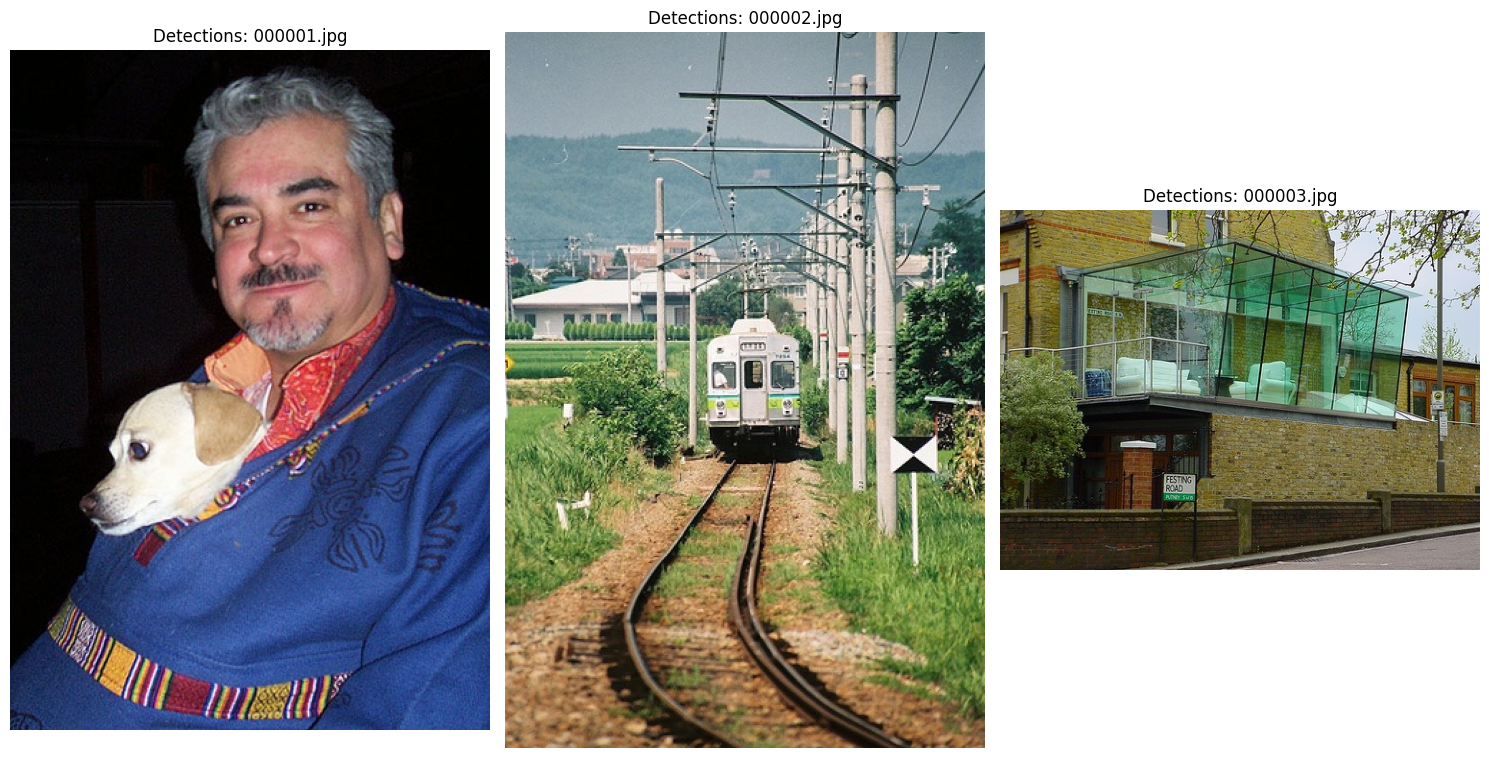

In [12]:
import matplotlib.patches as patches

def evaluate_detections(detections_results, test_ann_dir):
    all_gt_boxes = []
    all_pred_scores = []
    all_pred_matches = []
    total_gt_count = 0
    total_iou = 0
    total_matches = 0

    for res in detections_results:
        img_name = res['image']
        ann_path = os.path.join(test_ann_dir, img_name.replace('.jpg', '.xml'))
        gt_data = parse_voc_annotation(ann_path)
        total_gt_count += len(gt_data)

        preds = res['detections']
        # Sort predictions by score descending
        preds = sorted(preds, key=lambda x: x['score'], reverse=True)

        matched_gt = [False] * len(gt_data)

        for pred in preds:
            all_pred_scores.append(pred['score'])
            best_iou = 0
            best_gt_idx = -1

            for i, gt in enumerate(gt_data):
                if pred['label'] == gt['label']:
                    iou = calculate_iou(pred['box'], gt['bbox'])
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = i

            if best_iou >= 0.5 and best_gt_idx != -1 and not matched_gt[best_gt_idx]:
                all_pred_matches.append(1)
                matched_gt[best_gt_idx] = True
                total_iou += best_iou
                total_matches += 1
            else:
                all_pred_matches.append(0)

    # Calculate Precision-Recall and AP
    all_pred_matches = np.array(all_pred_matches)
    all_pred_scores = np.array(all_pred_scores)
    indices = np.argsort(all_pred_scores)[::-1]
    tp_cumsum = np.cumsum(all_pred_matches[indices])
    fp_cumsum = np.cumsum(1 - all_pred_matches[indices])

    recall = tp_cumsum / (total_gt_count + 1e-6)
    precision = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-6)

    ap = 0
    for t in np.arange(0, 1.1, 0.1):
        p = np.max(precision[recall >= t]) if np.any(recall >= t) else 0
        ap += p / 11.0

    avg_iou = total_iou / (total_matches + 1e-6)
    return ap, avg_iou

# 1. Calculate metrics
mAP, avg_iou = evaluate_detections(detections_results, test_ann_dir)
print(f'Evaluation Results (on {num_test_images} images):')
print(f'mAP: {mAP:.4f}')
print(f'Average IoU (for TP): {avg_iou:.4f}')

# 2. Visualize Sample Detections
plt.figure(figsize=(15, 10))
for i in range(min(3, len(detections_results))):
    res = detections_results[i]
    img = cv2.imread(os.path.join(test_image_dir, res['image']))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax = plt.subplot(1, 3, i + 1)
    ax.imshow(img)
    ax.set_title(f"Detections: {res['image']}")

    for det in res['detections']:
        x, y, w, h = det['box']
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        plt.text(x, y, f"{det['label']} {det['score']:.2f}", color='white', verticalalignment='top', bbox={'color': 'red', 'alpha': 0.5, 'pad': 0})
    plt.axis('off')

plt.tight_layout()
plt.show()